# Laboratorio de regresión - 3

## Análisis exploratorio de datos y limpieza

|                |   |
|:----------------|---|
| **Nombre**     | Carlos Enrique Nieves Ochoa |
| **Fecha**      | 6 de septiembre de 2026 |
| **Expediente** | 758210 |

**En los laboratorios y clases anteriores se ha visto que el modelo de regresión propuesto puede ser cualquier combinación lineal de factores independientes. Por lo tanto hay un número infinito de posibles modelos de regresión teóricos. ¿Cómo podemos deducir qué tipo de modelo podríamos necesitar?**

Lo podemos hacer con un análisis exploratorio donde primero revisaría qué significa cada variable, sus tipos de dato, sus rangos y la calidad de los registros, después observaría histogramas y gráficas entre la respuesta y los posibles factores para ver si la relación parece recta, curva o si participan varias variables. Con esa información se propone un modelo sencillo y luego se comprueba qué tan bien representa los datos.

### EDA

El primer paso antes de poder proponer un modelo para predecir datos es entender el conjunto de datos con el que se está trabajando.
- ¿Cuántas muestras tiene?
- ¿Cuántos factores tiene?
- ¿Quién o qué hizo la recolección de las observaciones?
- ¿Cómo se hizo el muestreo?
- ¿En qué año se hicieron las observaciones?
- ¿En dónde se realizaron las observaciones?

El propósito de un análisis exploratorio de datos (EDA - Exploratory Data Analysis) es entender la naturaleza de los datos, comprender las relaciones existentes entre las variables para poder realizar hipótesis sobre cómo se relaciona la variable dependiente con las independientes.

#### Ejercicio 1: Dataset

Utiliza el dataset "Heart Prediction Dataset (Quantum)". Carga los datos y revisa qué factores contiene.

In [22]:
# Cargar el archivo y revisar su estructura

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Heart Prediction Quantum Dataset.csv")

fac = ["Age", "Gender", "BloodPressure", "Cholesterol", "HeartRate"]

print("Número de muestras:", df.shape[0])
print("Número de variables:", df.shape[1])
print("Número de posibles factores:", len(fac))
print("Posibles factores:", fac)
print("Variable de respuesta: HeartDisease")

print(df.dtypes)

df.head()

Número de muestras: 500
Número de variables: 6
Número de posibles factores: 5
Posibles factores: ['Age', 'Gender', 'BloodPressure', 'Cholesterol', 'HeartRate']
Variable de respuesta: HeartDisease
Age              int64
Gender             str
BloodPressure      str
Cholesterol      int64
HeartRate        int64
HeartDisease     int64
dtype: object


,Age,Gender,BloodPressure,Cholesterol,HeartRate,HeartDisease
0,68,Hombre,105.00,191,107,1
1,58,Mujer,97.00,249,89,0
2,44,Mujer,93.00,190,82,1
3,72,Hombre,93.00,183,101,1
4,37,Mujer,145.00,166,103,1


Para cada factor, escribe qué significa cada variable.
- **¿Qué tipo de datos se observaron?**
    - Numéricos
        - Enteros
        - Flotantes
    - Categóricos
        - Ordinales
        - No ordinales
- **¿Qué rango de valores sería esperado que contuviera cada factor? E.g. No esperaría encontrar un valor de Age de $-4$.**

**Investiga los valores esperados para variables que no entiendas como BloodPressure, Cholesterol, etc.**

Para interpretar los rangos consideré que BloodPressure representa la presión sistólica y que Cholesterol representa el total, porque a partir del archivo no puedo ver otro detalle.

| Factor | ¿Qué representa? | Tipo de dato | Valores que esperaría |
|---|---|---|---|
| `Age` | Edad de la persona en años | Numérico entero | No debería ser negativa ni superar aproximadamente los 120 años. En un conjunto de adultos esperaría valores mayores de 18. |
| `Gender` | Género registrado | Categórico no ordinal | En este archivo las categorías correctas deben ser `hombre` y `mujer`. No existe un orden entre ellas. |
| `BloodPressure` | Presión arterial, aparentemente sistólica, en mmHg | Numérico flotante | Debe ser positiva. Una presión sistólica menor de 120 se considera normal, mientras que valores de 140 o más ya son altos y valores mayores de 180 son muy altos. |
| `Cholesterol` | Colesterol total en sangre, en mg/dL | Numérico entero | Debe ser positivo. Un valor cercano a 150 mg/dL es óptimo y uno mayor de 200 mg/dL puede considerarse alto. |
| `HeartRate` | Frecuencia cardiaca en latidos por minuto | Numérico entero | Debe ser positiva. En reposo, lo común para un adulto es de 60 a 100 latidos por minuto, aunque puede salir de ese rango por ejercicio, medicamentos o alguna condición de salud. |
| `HeartDisease` | Indica si se registró enfermedad cardiaca | Categórico binario, aunque está guardado como entero | Únicamente debería contener `0` y `1`; `0` significa que no y `1` que sí. |

**A partir de lo investigado, describe el dataset con tus palabras.**

El archivo contiene 500 registros y seis variables. Cinco describen características de cada persona, como la edad, el género, la presión arterial, el colesterol y la frecuencia cardiaca, mientras que HeartDisease indica si se registró o no una enfermedad cardiaca. Por ello, esta última podría tomarse como la variable de respuesta y las demás como posibles factores para explicarla o predecirla.

#### Ejercicio 2: Factores

Ahora que se tiene un mejor entendimiento del dataset y de los valores que podría tener cada variable, es momento de revisar que las observaciones en el dataset estén dentro de ese rango esperado.

**Crea un histograma para cada uno de los factores para ver el rango de los valores medidos y su distribución.**

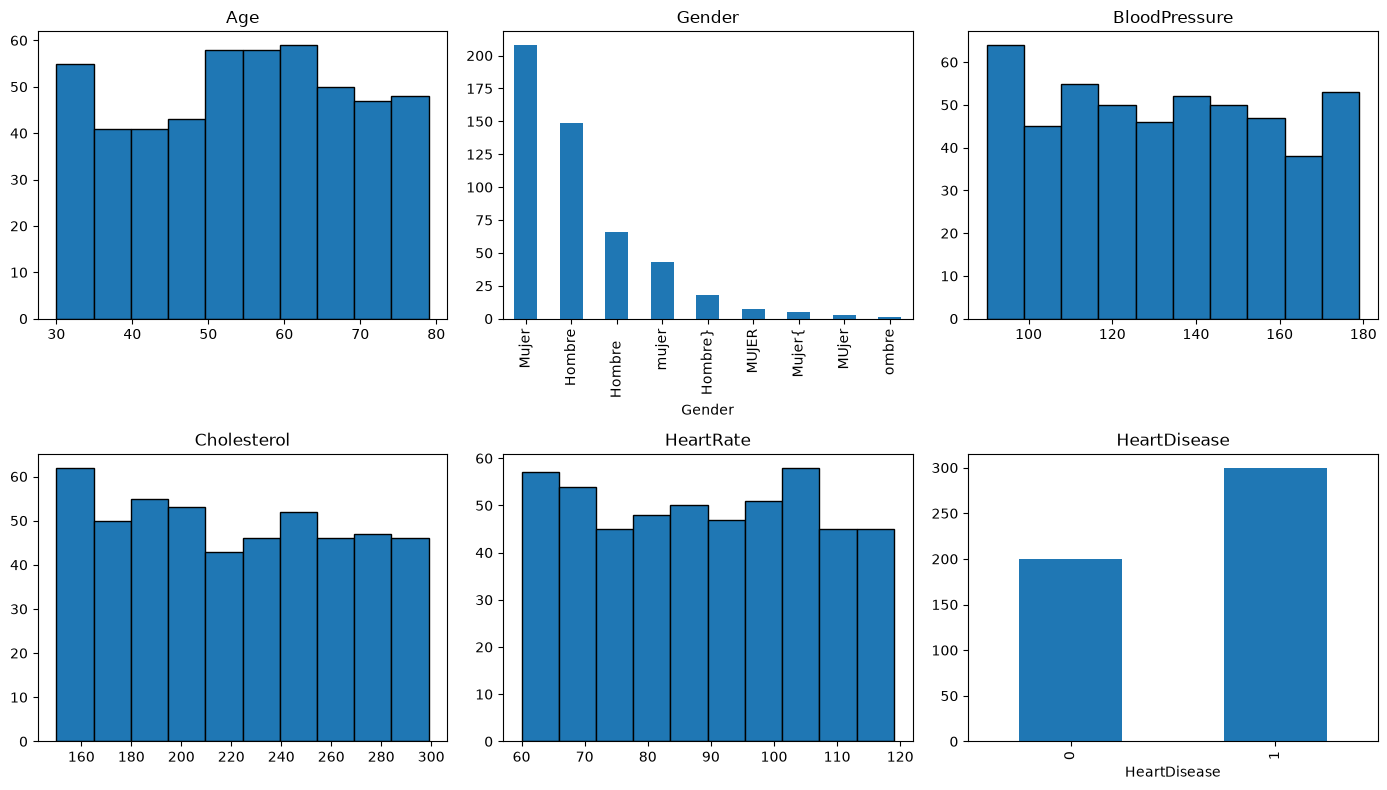

Rango de Age: 30 a 79
Rango de BloodPressure: 90.0 a 179.0
Rango de Cholesterol: 150 a 299
Rango de HeartRate: 60 a 119


In [23]:
# Revisar la distribución de cada factor
# BloodPressure se convierte sólo en la variable bp para poder graficarla.
# El contenido de df todavía no se modifica.

bp = df["BloodPressure"].str.replace(",", ".", regex=False)
bp = bp.astype(float)

fig, ax = plt.subplots(2, 3, figsize=(14, 8))

ax[0, 0].hist(df["Age"], bins=10, edgecolor="black")
ax[0, 0].set_title("Age")

df["Gender"].value_counts().plot(kind="bar", ax=ax[0, 1])
ax[0, 1].set_title("Gender")

ax[0, 2].hist(bp, bins=10, edgecolor="black")
ax[0, 2].set_title("BloodPressure")

ax[1, 0].hist(df["Cholesterol"], bins=10, edgecolor="black")
ax[1, 0].set_title("Cholesterol")

ax[1, 1].hist(df["HeartRate"], bins=10, edgecolor="black")
ax[1, 1].set_title("HeartRate")

df["HeartDisease"].value_counts().sort_index().plot(
    kind="bar", ax=ax[1, 2]
)
ax[1, 2].set_title("HeartDisease")

plt.tight_layout()
plt.show()

print("Rango de Age:", df["Age"].min(), "a", df["Age"].max())
print("Rango de BloodPressure:", bp.min(), "a", bp.max())
print("Rango de Cholesterol:", df["Cholesterol"].min(), "a", df["Cholesterol"].max())
print("Rango de HeartRate:", df["HeartRate"].min(), "a", df["HeartRate"].max())

**¿Parecen correctas estas distribuciones? ¿Qué valores atípicos encontraste? ¿Alguna inconsistencia? ¿Los problemas encontrados podrían ser casos reales?**

Los valores numéricos se encuentran dentro de rangos posibles, la edad va de 30 a 79 años, la presión de 90 a 179 mmHg, el colesterol de 150 a 299 mg/dL y la frecuencia cardiaca de 60 a 119 latidos por minuto. No aparece un valor claramente imposible, como una edad negativa o una frecuencia cardiaca de cero.

Lo que sí encontré fueron inconsistencias de captura porque BloodPressure está guardada como texto porque algunas cantidades usan punto decimal y otras usan coma. En Gender aparecen varias barras para categorías que deberían representar lo mismo, lo cual indica diferencias entre mayúsculas y minúsculas, espacios o errores de escritura. También hay valores de presión, colesterol y frecuencia cardiaca que no serían normales desde el punto de vista médico, pero eso no basta para eliminarlos, porque podrían corresponder a una persona con una condición real.

#### Ejercicio 3: Limpieza

Es muy común que haya errores al registrar observaciones. Puede ser que personas diferentes hayan registrado datos con un estilo diferente, o que haya habido un error de dedo. También podrían haber registros duplicados, o datos faltantes.

Por ejemplo, la columna BloodPressure tiene dos estilos diferentes para el punto decimal (americano y europeo).

**Utiliza `pandas.Series.str.replace` para cambiar el punto decimal de europeo a americano en la columna de BloodPressure. Después, cambia el tipo de dato de la columna a numérico. Dibuja el histograma de la variable corregida.**

Tipo de dato: float64


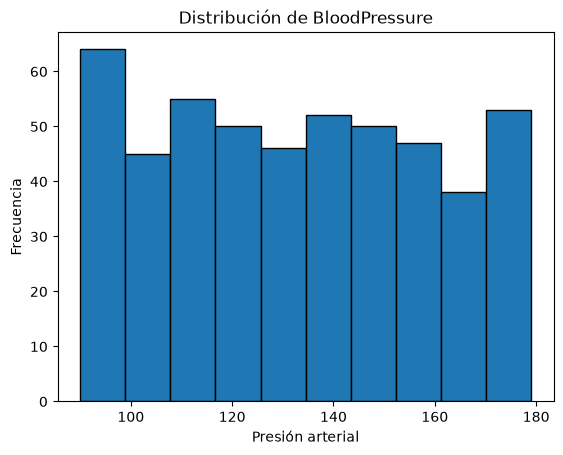

In [24]:
# Cambiar la coma por punto y convertir la columna a número

df["BloodPressure"] = df["BloodPressure"].str.replace(
    ",", ".", regex=False
)
df["BloodPressure"] = df["BloodPressure"].astype(float)

print("Tipo de dato:", df["BloodPressure"].dtype)

plt.hist(df["BloodPressure"], bins=10, edgecolor="black")
plt.xlabel("Presión arterial")
plt.ylabel("Frecuencia")
plt.title("Distribución de BloodPressure")
plt.show()

**La columna Gender tiene también errores de dedo y de estilo. Utiliza `pandas.Series.unique()` para encontrar las formas diferentes en las que se escribió "Hombre" y "Mujer".**

In [25]:
# Revisar las formas diferentes de escribir Gender

df["Gender"].unique()

<ArrowStringArray>
['Hombre   ',     'Mujer',     'ombre',     'mujer',     'MUjer',     'MUJER',
    'Mujer{',   'Hombre}',    'Hombre']
Length: 9, dtype: str

**La diferencia entre una mayúscula y minúscula para una computadora tiene que ver con la tabla ASCII. Para evitar esta variación utiliza `pandas.Series.str.lower()` para convertir todos las mayúsculas en minúsculas. Guarda el resultado en una variable auxiliar. Utiliza `unique()` una vez más para ver el resultado.**

In [26]:
# Pasar todo a minúsculas en una variable auxiliar

gen = df["Gender"].str.lower()
gen.unique()

<ArrowStringArray>
['hombre   ', 'mujer', 'ombre', 'mujer{', 'hombre}', 'hombre']
Length: 6, dtype: str

**Observamos que hay errores como espacios en blanco o errores de dedo. Utiliza `pandas.Series.str.rstrip("xxx")` para limpiar los caracteres indeseados.**

In [27]:
# Quitar espacios y llaves que aparecen al final

gen = gen.str.rstrip(" }{")
gen.unique()

<ArrowStringArray>
['hombre', 'mujer', 'ombre']
Length: 3, dtype: str

**Utiliza un filtro para corregir el typo de la 'h' faltante para la categoría "hombre".**

In [28]:
# Corregir el registro al que le falta la letra h

gen.loc[gen == "ombre"] = "hombre"
gen.unique()

<ArrowStringArray>
['hombre', 'mujer']
Length: 2, dtype: str

**Asigna "hombre"=1 y "mujer"=0 (Ojo con los tipos de dato. Considera que 0 es diferente a "0").**

In [29]:
# Convertir las categorías a números enteros

gen = gen.map({"hombre": 1, "mujer": 0})

print("Valores únicos:", gen.unique())
print("Tipo de dato:", gen.dtype)

Valores únicos: [1 0]
Tipo de dato: int64


**Reescribe el resultado en el dataset original.**

In [30]:
# Guardar la columna corregida en el dataset original

df["Gender"] = gen
df.head()

,Age,Gender,BloodPressure,Cholesterol,HeartRate,HeartDisease
0,68,1,105.0,191,107,1
1,58,0,97.0,249,89,0
2,44,0,93.0,190,82,1
3,72,1,93.0,183,101,1
4,37,0,145.0,166,103,1


**Para asegurarnos que no haya duplicados, utiliza `pd.DataFrame.drop_duplicates()`**

In [31]:
# Eliminar filas duplicadas, si existen

n = df.shape[0]
df = df.drop_duplicates()

print("Duplicados eliminados:", n - df.shape[0])
print("Filas restantes:", df.shape[0])

Duplicados eliminados: 0
Filas restantes: 500


**Para los valores faltantes se podría imputar, pero por ahora sólo elimínalos (si es que hay) con `pd.DataFrame.dropna()`**

In [32]:
# Eliminar filas con valores faltantes, si existen

n = df.shape[0]
df = df.dropna()

print("Filas con faltantes eliminadas:", n - df.shape[0])
print("Filas restantes:", df.shape[0])

Filas con faltantes eliminadas: 0
Filas restantes: 500


#### Ejercicio 4: Verificación

**Ahora que entendemos qué significan nuestras variables y que las limpiamos, vuelve a generar histogramas para cada variable.**

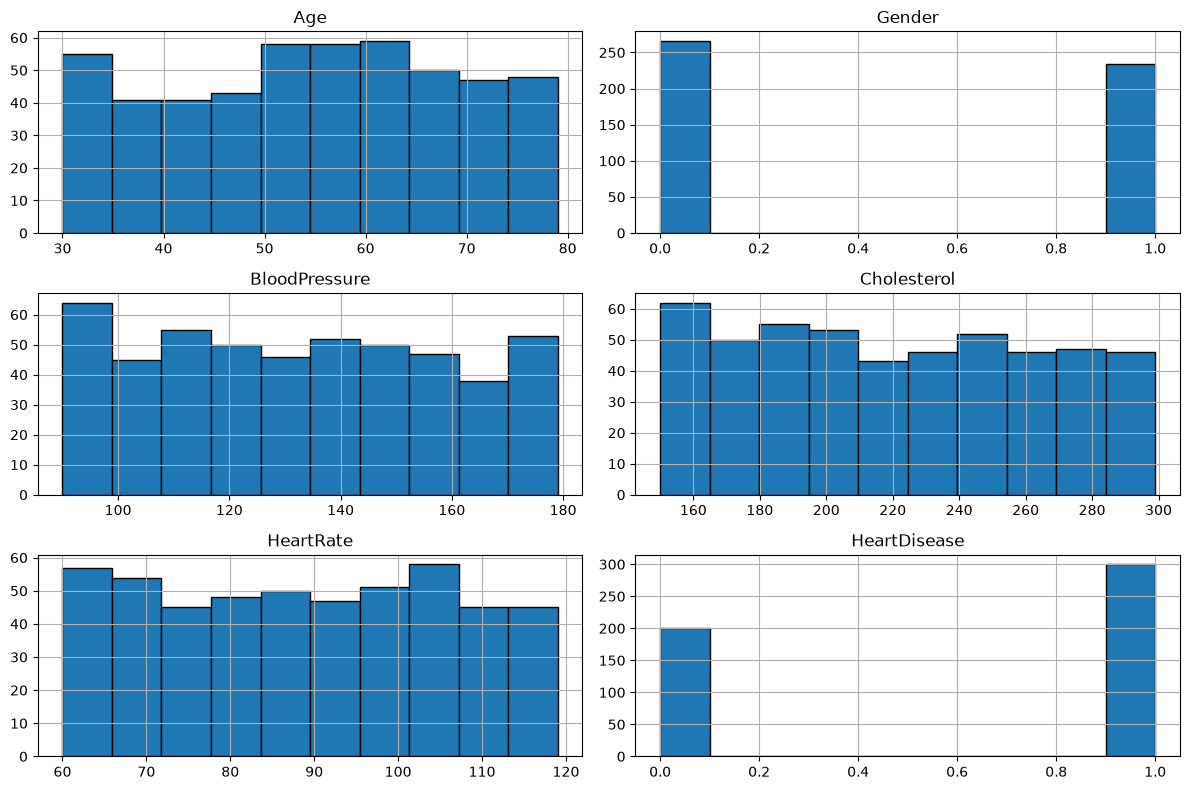

In [33]:
# Histogramas con los datos limpios

df.hist(figsize=(12, 8), bins=10, edgecolor="black")
plt.tight_layout()
plt.show()

Encuentra la siguiente información para las variables numéricas:
- media
- mediana
- desviación estándar
- mínimo
- máximo

**Genera un diagrama de caja para cada una. ¿Consideras que hay valores atípicos (outliers)?**

,Media,Mediana,Desviación estándar,Mínimo,Máximo
Age,54.864,55.0,14.315,30.0,79.0
BloodPressure,132.874,132.0,26.419,90.0,179.0
Cholesterol,221.500,221.0,43.864,150.0,299.0
HeartRate,88.766,89.0,17.417,60.0,119.0


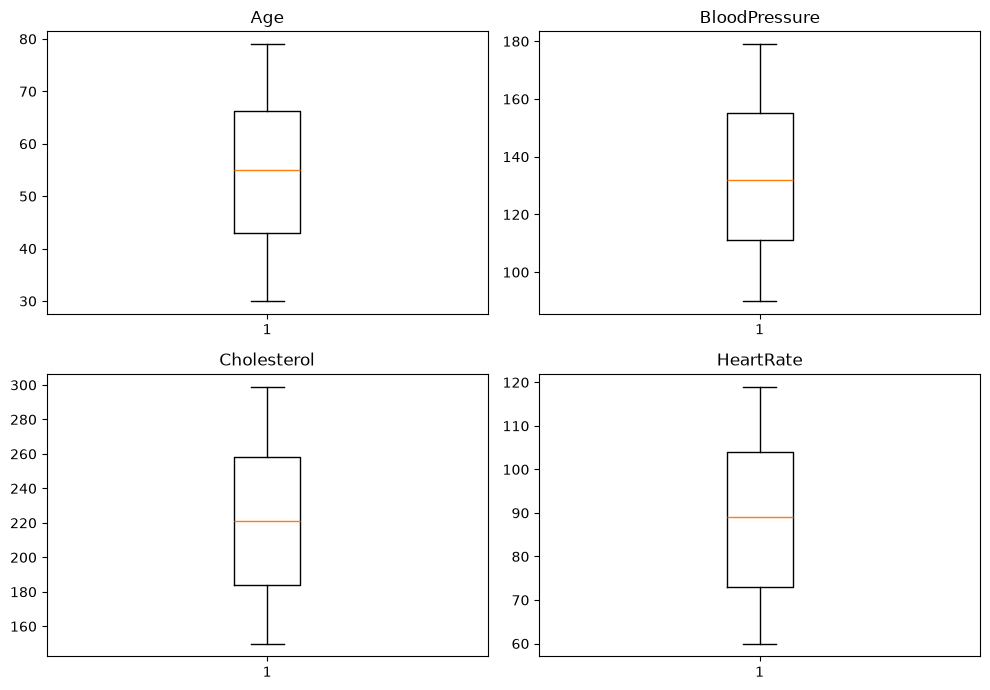

In [34]:
# Resumen de las variables numéricas

num = ["Age", "BloodPressure", "Cholesterol", "HeartRate"]

res = pd.DataFrame({
    "Media": df[num].mean(),
    "Mediana": df[num].median(),
    "Desviación estándar": df[num].std(),
    "Mínimo": df[num].min(),
    "Máximo": df[num].max()
})

display(res.round(3))

# Diagramas de caja

fig, ax = plt.subplots(2, 2, figsize=(10, 7))

for c, a in zip(num, ax.flatten()):
    a.boxplot(df[c])
    a.set_title(c)

plt.tight_layout()
plt.show()

En los diagramas de caja no aparecen puntos fuera de los bigotes, así que con este criterio no se detectan outliers en las cuatro variables numéricas. Hay valores que pueden ser altos desde el punto de vista médico, pero siguen dentro del patrón del conjunto y no conviene borrarlos solamente por eso. `Gender` y `HeartDisease` no se incluyeron en esta tabla porque, aunque ahora están guardadas con números, esos números representan categorías y no cantidades que tenga sentido promediar.

**Encuentra la siguiente información para las variables categóricas:**
- tabla de frecuencias
- valores únicos

In [35]:
# Frecuencias y valores únicos de las variables categóricas

cat = ["Gender", "HeartDisease"]

for c in cat:
    print(df[c].value_counts().sort_index())
    print("Valores únicos:", df[c].unique())
    print()

Gender
0    266
1    234
Name: count, dtype: int64
Valores únicos: [1 0]

HeartDisease
0    200
1    300
Name: count, dtype: int64
Valores únicos: [1 0]



Después de la limpieza, Gender tiene 266 registros con valor 0, que representan mujer, y 234 con valor 1, que representan hombre. HeartDisease tiene 200 registros con valor 0 y 300 con valor 1. En ambos casos los únicos valores son 0 y 1, como se esperaba.

## Referencia

Dataset original tomado de: https://www.kaggle.com/datasets/shantanugarg274/heart-prediction-dataset-quantum

Rangos médicos consultados en:
- https://www.heart.org/en/health-topics/high-blood-pressure/understanding-blood-pressure-readings
- https://www.heart.org/en/healthy-living/exercise-and-physical-activity/fitness-basics/target-heart-rates
- https://www.cdc.gov/cholesterol/about/index.html